# Statistical Analysis: Collaborative Listeners
## Bridging Human Intuition and AI Memory through Emotional Grounding

**Research Question:** What is the effect of an agent with a reflective emotional memory compared to a memoryless baseline LLM in establishing perceived empathy and rapport during an emotionally complex conversation?

**Design:** Between-subjects (N=30, 15 per group)
- **Condition 1 (Treatment):** Agent with active emotional memory (updates reflective summary every 3 turns)
- **Condition 2 (Control):** Memoryless baseline (same LLM, no memory of emotional states)

**Hypotheses:**
- **H₁:** Users report significantly higher perceived empathy and rapport with the memory-augmented agent
- **H₀:** No significant difference between conditions

**Questionnaires:**
- RoPE Scale (Robot's Perceived Empathy) — Charrier et al., 2019
- CCR Scale (Connection-Coordination Rapport) — Lin et al., 2025

---
## 1. Setup & Data Loading

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [5]:
# Load both sheets
df_memory = pd.read_excel('data.xlsx', sheet_name='Memory')
df_memoryless = pd.read_excel('data.xlsx', sheet_name='Memory-Less')

print(f'Memory condition: {len(df_memory)} participants')
print(f'Memory-Less condition: {len(df_memoryless)} participants')
print(f'\nMemory columns ({len(df_memory.columns)}): first 10 shown')
for i, col in enumerate(df_memory.columns[:10]):
    print(f'  {i}: {col}')

Memory condition: 15 participants
Memory-Less condition: 15 participants

Memory columns (45): first 10 shown
  0: Id
  1: Start time
  2: Completion time
  3: Email
  4: Name
  5: I have read and understood the information above and agree to participate in this study.

  6: Name1
  7: Empathic Understanding (EU)
.The agent appreciates exactly how the things I experience feel to me.
  8: Empathic Understanding (EU)
.The agent knows me and my needs.
  9: Empathic Understanding (EU)
.The agent cares about my feelings.


---
## 2. Questionnaire Scoring

### 2.1 RoPE Scale Scoring

The RoPE scale has 18 items: 8 Empathic Understanding (EU), 8 Empathic Response (ER), and 4 filler items (not scored).

**Negative items** (multiplied by −1 before summing): EU4, EU7, ER1, ER2, ER8

**Filler items** (excluded): FI1 (natural), FI2 (knows what doing), FI3 (responsible), FI4 (anxious)

In [7]:
# ============================================================
# Likert text-to-numeric mapping
# ============================================================
likert_map = {
    'Strongly disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly agree': 5
}

def map_likert(value):
    """Convert Likert text to numeric, pass through if already numeric."""
    if isinstance(value, (int, float)):
        return int(value)
    return likert_map.get(str(value).strip(), np.nan)

# ============================================================
# RoPE item column indices (0-based from column list)
# Mapping Excel columns to RoPE scale items
# ============================================================

# Get column names for reference
cols = df_memory.columns.tolist()

# EU items (columns 7-15 in 0-indexed = the first 10 empathy columns)
# Col 7:  EU1 - appreciates how things feel (positive)
# Col 8:  EU2 - knows me and my needs (positive)
# Col 9:  EU3 - cares about feelings (positive)
# Col 10: FI1 - acts natural (FILLER - skip)
# Col 11: EU4 - does not understand me (NEGATIVE)
# Col 12: EU5 - perceives individual characteristics (positive)
# Col 13: FI2 - knows what it is doing (FILLER - skip)
# Col 14: EU6 - understands whole of what I mean (positive)
# Col 15: EU7 - reacts but does not see how I feel (NEGATIVE)
# Col 16: EU8 - seems to feel bad when I am sad (positive)

eu_positive_cols = [cols[7], cols[8], cols[9], cols[12], cols[14], cols[16]]
eu_negative_cols = [cols[11], cols[15]]  # EU4, EU7
eu_filler_cols = [cols[10], cols[13]]    # FI1, FI2

# ER items (columns 17-26 in 0-indexed)
# Col 17: ER1 - good/bad makes no difference (NEGATIVE)
# Col 18: ER2 - acts just the same (NEGATIVE)
# Col 19: ER3 - comforts when upset (positive)
# Col 20: FI3 - responsible for actions (FILLER - skip)
# Col 21: ER4 - encourages me (positive)
# Col 22: ER5 - praises me (positive)
# Col 23: ER6 - helps when I need it (positive)
# Col 24: FI4 - I feel anxious (FILLER - skip)
# Col 25: ER7 - knows when I want to talk (positive)
# Col 26: ER8 - response is fixed and automatic (NEGATIVE)

er_positive_cols = [cols[19], cols[21], cols[22], cols[23], cols[25]]
er_negative_cols = [cols[17], cols[18], cols[26]]  # ER1, ER2, ER8
er_filler_cols = [cols[20], cols[24]]              # FI3, FI4

print('RoPE Scale Item Mapping:')
print(f'  EU positive items ({len(eu_positive_cols)}): EU1, EU2, EU3, EU5, EU6, EU8')
print(f'  EU negative items ({len(eu_negative_cols)}): EU4, EU7')
print(f'  EU fillers ({len(eu_filler_cols)}): FI1, FI2')
print(f'  ER positive items ({len(er_positive_cols)}): ER3, ER4, ER5, ER6, ER7')
print(f'  ER negative items ({len(er_negative_cols)}): ER1, ER2, ER8')
print(f'  ER fillers ({len(er_filler_cols)}): FI3, FI4')
print(f'  Total scored items: {len(eu_positive_cols) + len(eu_negative_cols) + len(er_positive_cols) + len(er_negative_cols)} (expected: 16)')

RoPE Scale Item Mapping:
  EU positive items (6): EU1, EU2, EU3, EU5, EU6, EU8
  EU negative items (2): EU4, EU7
  EU fillers (2): FI1, FI2
  ER positive items (5): ER3, ER4, ER5, ER6, ER7
  ER negative items (3): ER1, ER2, ER8
  ER fillers (2): FI3, FI4
  Total scored items: 16 (expected: 16)


In [10]:
# ============================================================
# Score RoPE for both conditions
# ============================================================
def score_rope(df):
    """Calculate RoPE sub-scale and total scores.
    
    Scoring (per Charrier et al., 2019, Table I):
    - Map Likert text to 1-5
    - Multiply negative items by -1
    - EU sub-scale = sum of 8 EU items
    - ER sub-scale = sum of 8 ER items  
    - Total empathy = EU + ER
    """
    # Convert all RoPE items to numeric
    all_rope_cols = eu_positive_cols + eu_negative_cols + er_positive_cols + er_negative_cols
    rope_numeric = df[all_rope_cols].applymap(map_likert)
    
    # EU sub-scale: sum positive items + sum (negative items * -1)
    eu_pos_sum = rope_numeric[eu_positive_cols].sum(axis=1)
    eu_neg_sum = rope_numeric[eu_negative_cols].sum(axis=1) * (-1)
    eu_total = eu_pos_sum + eu_neg_sum
    
    # ER sub-scale: sum positive items + sum (negative items * -1)
    er_pos_sum = rope_numeric[er_positive_cols].sum(axis=1)
    er_neg_sum = rope_numeric[er_negative_cols].sum(axis=1) * (-1)
    er_total = er_pos_sum + er_neg_sum
    
    # Total empathy
    total_empathy = eu_total + er_total
    
    return eu_total, er_total, total_empathy

# Score both conditions
mem_eu, mem_er, mem_empathy = score_rope(df_memory)
ml_eu, ml_er, ml_empathy = score_rope(df_memoryless)

print('RoPE Scoring Complete')
print(f'  EU sub-scale range: [{min(mem_eu.min(), ml_eu.min())}, {max(mem_eu.max(), ml_eu.max())}]')
print(f'  ER sub-scale range: [{min(mem_er.min(), ml_er.min())}, {max(mem_er.max(), ml_er.max())}]')
print(f'  Total empathy range: [{min(mem_empathy.min(), ml_empathy.min())}, {max(mem_empathy.max(), ml_empathy.max())}]')

RoPE Scoring Complete
  EU sub-scale range: [9, 23]
  ER sub-scale range: [6, 20]
  Total empathy range: [17, 43]


### 2.2 CCR Scale Scoring

The CCR scale has 18 items: 12 Connection and 6 Coordination (Lin et al., 2025).

**Scoring:**
1. Connection score = mean of 12 Connection items
2. Coordination score = mean of 6 Coordination items
3. Total rapport = mean of (Connection score, Coordination score)

In [11]:
# ============================================================
# CCR item columns
# ============================================================
# Connection: cols 27-38 (12 items) - stored as numeric in Excel
connection_cols = cols[27:39]  # Warmth through Connection
# Coordination: cols 39-44 (6 items) - stored as text in Excel
coordination_cols = cols[39:45]  # Coordination through Engagement

print('CCR Scale Item Mapping:')
print(f'  Connection items ({len(connection_cols)}):')
for c in connection_cols:
    print(f'    - {c.split(".")[-1]}')
print(f'  Coordination items ({len(coordination_cols)}):')
for c in coordination_cols:
    print(f'    - {c.split(".")[-1]}')

CCR Scale Item Mapping:
  Connection items (12):
    - Warmth
    - Empathy 
    - Friendliness
    - Sympathy
    - Closeness
    - Positivity
    - Liking each other
    - Enthusiasm
    - Respect
    - Getting along
    - Excitement
    - Connection
  Coordination items (6):
    - Coordination
    - Focus
    - Attentiveness
    - Smooth flow
    - Equal participation
    - Engagement


In [14]:
# ============================================================
# Score CCR for both conditions
# ============================================================
def score_ccr(df):
    """Calculate CCR factor scores and total rapport.
    
    Scoring (per Lin et al., 2025):
    - Connection score = average of 12 Connection items (1-5)
    - Coordination score = average of 6 Coordination items (1-5)
    - Total rapport = average of Connection and Coordination scores
    """
    # Connection items (already numeric)
    conn = df[connection_cols].applymap(map_likert)
    conn_score = conn.mean(axis=1)
    
    # Coordination items (text -> numeric)
    coord = df[coordination_cols].applymap(map_likert)
    coord_score = coord.mean(axis=1)
    
    # Total rapport = average of the two factor scores
    total_rapport = (conn_score + coord_score) / 2
    
    return conn_score, coord_score, total_rapport

# Score both conditions
mem_conn, mem_coord, mem_rapport = score_ccr(df_memory)
ml_conn, ml_coord, ml_rapport = score_ccr(df_memoryless)

print('CCR Scoring Complete')
print(f'  Connection score range: [{min(mem_conn.min(), ml_conn.min()):.2f}, {max(mem_conn.max(), ml_conn.max()):.2f}]')
print(f'  Coordination score range: [{min(mem_coord.min(), ml_coord.min()):.2f}, {max(mem_coord.max(), ml_coord.max()):.2f}]')
print(f'  Total rapport range: [{min(mem_rapport.min(), ml_rapport.min()):.2f}, {max(mem_rapport.max(), ml_rapport.max()):.2f}]')

CCR Scoring Complete
  Connection score range: [1.92, 4.75]
  Coordination score range: [2.67, 5.00]
  Total rapport range: [2.46, 4.75]


In [15]:
# ============================================================
# Assemble all scores into a single DataFrame
# ============================================================
scores_memory = pd.DataFrame({
    'Condition': 'Memory',
    'EU_subscale': mem_eu,
    'ER_subscale': mem_er,
    'Total_Empathy': mem_empathy,
    'Connection': mem_conn,
    'Coordination': mem_coord,
    'Total_Rapport': mem_rapport
})

scores_memoryless = pd.DataFrame({
    'Condition': 'Memory-Less',
    'EU_subscale': ml_eu,
    'ER_subscale': ml_er,
    'Total_Empathy': ml_empathy,
    'Connection': ml_conn,
    'Coordination': ml_coord,
    'Total_Rapport': ml_rapport
})

df_scores = pd.concat([scores_memory, scores_memoryless], ignore_index=True)

print('Combined scores DataFrame:')
print(f'  Shape: {df_scores.shape}')
print(f'  Conditions: {df_scores["Condition"].value_counts().to_dict()}')
df_scores.head()

Combined scores DataFrame:
  Shape: (30, 7)
  Conditions: {'Memory': 15, 'Memory-Less': 15}


,Condition,EU_subscale,ER_subscale,Total_Empathy,Connection,Coordination,Total_Rapport
0,Memory,18,15,33,3.500000,3.666667,3.583333
1,Memory,22,14,36,4.000000,3.666667,3.833333
2,Memory,15,8,23,3.666667,3.833333,3.750000
3,Memory,20,11,31,3.750000,3.666667,3.708333
4,Memory,22,16,38,4.666667,4.666667,4.666667


---
## 3. Descriptive Statistics

In [16]:
# ============================================================
# Descriptive statistics per condition per metric
# ============================================================
metrics = ['Total_Empathy', 'EU_subscale', 'ER_subscale', 'Total_Rapport', 'Connection', 'Coordination']
metric_labels = {
    'Total_Empathy': 'Total Empathy (RoPE)',
    'EU_subscale': 'Empathic Understanding (EU)',
    'ER_subscale': 'Empathic Response (ER)',
    'Total_Rapport': 'Total Rapport (CCR)',
    'Connection': 'Connection Factor',
    'Coordination': 'Coordination Factor'
}

desc_stats = []
for metric in metrics:
    for condition in ['Memory', 'Memory-Less']:
        data = df_scores[df_scores['Condition'] == condition][metric]
        desc_stats.append({
            'Metric': metric_labels[metric],
            'Condition': condition,
            'N': len(data),
            'Mean': data.mean(),
            'SD': data.std(ddof=1),
            'Median': data.median(),
            'Min': data.min(),
            'Max': data.max()
        })

df_desc = pd.DataFrame(desc_stats)
# Format for display
df_desc_display = df_desc.copy()
for col in ['Mean', 'SD', 'Median', 'Min', 'Max']:
    df_desc_display[col] = df_desc_display[col].apply(lambda x: f'{x:.3f}')

print('Descriptive Statistics')
print('=' * 90)
df_desc_display

Descriptive Statistics


,Metric,Condition,N,Mean,SD,Median,Min,Max
0,Total Empathy (RoPE),Memory,15,28.267,6.453,29.000,17.000,38.000
1,Total Empathy (RoPE),Memory-Less,15,32.467,6.046,31.000,22.000,43.000
2,Empathic Understanding (EU),Memory,15,16.667,4.012,17.000,9.000,22.000
3,Empathic Understanding (EU),Memory-Less,15,18.533,2.997,18.000,12.000,23.000
4,Empathic Response (ER),Memory,15,11.600,3.542,11.000,6.000,18.000
5,Empathic Response (ER),Memory-Less,15,13.933,3.712,14.000,9.000,20.000
6,Total Rapport (CCR),Memory,15,3.603,0.611,3.708,2.458,4.667
7,Total Rapport (CCR),Memory-Less,15,3.850,0.511,3.750,3.000,4.750
8,Connection Factor,Memory,15,3.428,0.747,3.500,1.917,4.667
9,Connection Factor,Memory-Less,15,3.744,0.497,3.750,3.083,4.750


---
## 4. Assumption Checking

Before selecting the appropriate statistical test, we check two parametric assumptions:
1. **Normality** — Shapiro-Wilk test (appropriate for small samples, n < 50)
2. **Equality of variances** — Levene's test (Brown-Forsythe variant, using median)

In [17]:
# ============================================================
# Assumption checking: Normality & Variance Equality
# ============================================================
alpha = 0.05

assumption_results = []
for metric in metrics:
    mem_data = df_scores[df_scores['Condition'] == 'Memory'][metric].values
    ml_data = df_scores[df_scores['Condition'] == 'Memory-Less'][metric].values
    
    # Shapiro-Wilk for each group
    sw_mem_stat, sw_mem_p = stats.shapiro(mem_data)
    sw_ml_stat, sw_ml_p = stats.shapiro(ml_data)
    
    # Levene's test (Brown-Forsythe variant: center='median')
    lev_stat, lev_p = stats.levene(mem_data, ml_data, center='median')
    
    # Determine normality and equal variance
    normal_mem = sw_mem_p > alpha
    normal_ml = sw_ml_p > alpha
    both_normal = normal_mem and normal_ml
    equal_var = lev_p > alpha
    
    assumption_results.append({
        'Metric': metric_labels[metric],
        'SW Memory (W)': f'{sw_mem_stat:.4f}',
        'SW Memory (p)': f'{sw_mem_p:.4f}',
        'Normal (Memory)': '✓' if normal_mem else '✗',
        'SW MemLess (W)': f'{sw_ml_stat:.4f}',
        'SW MemLess (p)': f'{sw_ml_p:.4f}',
        'Normal (MemLess)': '✓' if normal_ml else '✗',
        'Levene (F)': f'{lev_stat:.4f}',
        'Levene (p)': f'{lev_p:.4f}',
        'Equal Var': '✓' if equal_var else '✗',
        '_both_normal': both_normal,
        '_equal_var': equal_var
    })

df_assumptions = pd.DataFrame(assumption_results)
print('Assumption Tests (α = 0.05)')
print('Shapiro-Wilk: H₀ = data is normally distributed (p > 0.05 → assume normal)')
print('Levene\'s test: H₀ = variances are equal (p > 0.05 → assume equal)')
print('=' * 100)
df_assumptions.drop(columns=['_both_normal', '_equal_var'])

Assumption Tests (α = 0.05)
Shapiro-Wilk: H₀ = data is normally distributed (p > 0.05 → assume normal)
Levene's test: H₀ = variances are equal (p > 0.05 → assume equal)


,Metric,SW Memory (W),SW Memory (p),Normal (Memory),SW MemLess (W),SW MemLess (p),Normal (MemLess),Levene (F),Levene (p),Equal Var
0,Total Empathy (RoPE),0.9434,0.4267,✓,0.9692,0.8454,✓,0.0224,0.8820,✓
1,Empathic Understanding (EU),0.9477,0.4896,✓,0.9509,0.5395,✓,1.1889,0.2848,✓
2,Empathic Response (ER),0.9523,0.5611,✓,0.9154,0.1637,✓,0.3706,0.5476,✓
3,Total Rapport (CCR),0.9712,0.8760,✓,0.9611,0.7111,✓,0.2643,0.6112,✓
4,Connection Factor,0.9733,0.9039,✓,0.9578,0.6534,✓,1.7649,0.1947,✓
5,Coordination Factor,0.9532,0.5765,✓,0.9756,0.9311,✓,0.1604,0.6918,✓


In [18]:
# ============================================================
# Test selection summary
# ============================================================
print('Test Selection Based on Assumptions:')
print('=' * 70)
for i, metric in enumerate(metrics):
    r = assumption_results[i]
    both_normal = r['_both_normal']
    equal_var = r['_equal_var']
    
    if both_normal and equal_var:
        test = "Independent t-test (one-tailed)"
    elif both_normal and not equal_var:
        test = "Welch's t-test (one-tailed)"
    else:
        test = "Mann-Whitney U (one-tailed)"
    
    print(f'  {metric_labels[metric]:.<45} {test}')

Test Selection Based on Assumptions:
  Total Empathy (RoPE)......................... Independent t-test (one-tailed)
  Empathic Understanding (EU).................. Independent t-test (one-tailed)
  Empathic Response (ER)....................... Independent t-test (one-tailed)
  Total Rapport (CCR).......................... Independent t-test (one-tailed)
  Connection Factor............................ Independent t-test (one-tailed)
  Coordination Factor.......................... Independent t-test (one-tailed)


---
## 5. Hypothesis Testing

**Direction:** One-tailed test (H₁: Memory > Memory-Less)  
**Significance level:** α = 0.05

**Decision tree:**
- Both groups normal + equal variances → Independent samples t-test
- Both groups normal + unequal variances → Welch's t-test
- Non-normal distribution → Mann-Whitney U test

In [19]:
# ============================================================
# Cohen's d for independent samples
# ============================================================
def cohens_d(group1, group2):
    """Calculate Cohen's d for independent samples (pooled SD)."""
    n1, n2 = len(group1), len(group2)
    var1, var2 = group1.var(ddof=1), group2.var(ddof=1)
    # Pooled standard deviation
    pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
    d = (group1.mean() - group2.mean()) / pooled_sd
    return d

def cohens_d_ci(d, n1, n2, confidence=0.95):
    """Approximate CI for Cohen's d using non-central t distribution."""
    se = np.sqrt((n1 + n2) / (n1 * n2) + d**2 / (2 * (n1 + n2)))
    z = stats.norm.ppf((1 + confidence) / 2)
    return d - z * se, d + z * se

# ============================================================
# Run hypothesis tests
# ============================================================
results = []

for i, metric in enumerate(metrics):
    mem_data = df_scores[df_scores['Condition'] == 'Memory'][metric].values
    ml_data = df_scores[df_scores['Condition'] == 'Memory-Less'][metric].values
    
    both_normal = assumption_results[i]['_both_normal']
    equal_var = assumption_results[i]['_equal_var']
    
    # Select test
    if both_normal and equal_var:
        # Independent t-test (one-tailed: Memory > Memory-Less)
        t_stat, p_two = stats.ttest_ind(mem_data, ml_data, equal_var=True)
        p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
        test_name = 'Independent t-test'
        df_val = len(mem_data) + len(ml_data) - 2
        stat_str = f't({df_val}) = {t_stat:.4f}'
        
    elif both_normal and not equal_var:
        # Welch's t-test (one-tailed)
        t_stat, p_two = stats.ttest_ind(mem_data, ml_data, equal_var=False)
        p_one = p_two / 2 if t_stat > 0 else 1 - p_two / 2
        test_name = "Welch's t-test"
        # Welch-Satterthwaite df
        n1, n2 = len(mem_data), len(ml_data)
        v1, v2 = mem_data.var(ddof=1), ml_data.var(ddof=1)
        df_val = ((v1/n1 + v2/n2)**2) / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
        stat_str = f't({df_val:.1f}) = {t_stat:.4f}'
        
    else:
        # Mann-Whitney U (one-tailed: Memory > Memory-Less)
        u_stat, p_two = stats.mannwhitneyu(mem_data, ml_data, alternative='two-sided')
        # One-tailed: we want Memory > Memory-Less
        _, p_one = stats.mannwhitneyu(mem_data, ml_data, alternative='greater')
        test_name = 'Mann-Whitney U'
        stat_str = f'U = {u_stat:.1f}'
        df_val = None
    
    # Effect size (Cohen's d)
    d = cohens_d(mem_data, ml_data)
    d_ci_low, d_ci_high = cohens_d_ci(d, len(mem_data), len(ml_data))
    
    # Significance
    significant = p_one < alpha
    
    results.append({
        'Metric': metric_labels[metric],
        'Test': test_name,
        'Statistic': stat_str,
        'p (one-tailed)': p_one,
        'Cohen\'s d': d,
        'd 95% CI': f'[{d_ci_low:.3f}, {d_ci_high:.3f}]',
        'Significant': '✓ Yes' if significant else '✗ No'
    })

df_results = pd.DataFrame(results)

# Format p-values
df_results_display = df_results.copy()
df_results_display['p (one-tailed)'] = df_results_display['p (one-tailed)'].apply(
    lambda x: f'{x:.4f}' if x >= 0.001 else f'{x:.2e}'
)
df_results_display["Cohen's d"] = df_results_display["Cohen's d"].apply(lambda x: f'{x:.4f}')

print('Hypothesis Test Results (α = 0.05, one-tailed: Memory > Memory-Less)')
print('=' * 110)
df_results_display

Hypothesis Test Results (α = 0.05, one-tailed: Memory > Memory-Less)


,Metric,Test,Statistic,p (one-tailed),Cohen's d,d 95% CI,Significant
0,Total Empathy (RoPE),Independent t-test,t(28) = -1.8396,0.9618,-0.6717,"[-1.407, 0.064]",✗ No
1,Empathic Understanding (EU),Independent t-test,t(28) = -1.4437,0.9200,-0.5272,"[-1.255, 0.201]",✗ No
2,Empathic Response (ER),Independent t-test,t(28) = -1.7614,0.9555,-0.6432,"[-1.377, 0.091]",✗ No
3,Total Rapport (CCR),Independent t-test,t(28) = -1.2022,0.8803,-0.4390,"[-1.163, 0.285]",✗ No
4,Connection Factor,Independent t-test,t(28) = -1.3662,0.9086,-0.4989,"[-1.226, 0.228]",✗ No
5,Coordination Factor,Independent t-test,t(28) = -0.8259,0.7921,-0.3016,"[-1.021, 0.418]",✗ No


In [20]:
# ============================================================
# Summary interpretation
# ============================================================
print('INTERPRETATION SUMMARY')
print('=' * 70)
for r in results:
    metric = r['Metric']
    p = r['p (one-tailed)']
    d = r["Cohen's d"]
    sig = r['Significant']
    
    # Effect size interpretation
    abs_d = abs(d)
    if abs_d < 0.2:
        d_label = 'negligible'
    elif abs_d < 0.5:
        d_label = 'small'
    elif abs_d < 0.8:
        d_label = 'medium'
    else:
        d_label = 'large'
    
    direction = 'higher' if d > 0 else 'lower'
    
    print(f'\n{metric}:')
    print(f'  {r["Test"]}: {r["Statistic"]}, p = {p:.4f}')
    print(f'  Cohen\'s d = {d:.3f} ({d_label} effect, Memory scored {direction})')
    if '✓' in sig:
        print(f'  → SIGNIFICANT: Reject H₀. The memory condition shows significantly')
        print(f'    {direction} {metric.lower()} than the memoryless condition.')
    else:
        print(f'  → NOT SIGNIFICANT: Fail to reject H₀. No significant difference')
        print(f'    detected between conditions for {metric.lower()}.')

INTERPRETATION SUMMARY

Total Empathy (RoPE):
  Independent t-test: t(28) = -1.8396, p = 0.9618
  Cohen's d = -0.672 (medium effect, Memory scored lower)
  → NOT SIGNIFICANT: Fail to reject H₀. No significant difference
    detected between conditions for total empathy (rope).

Empathic Understanding (EU):
  Independent t-test: t(28) = -1.4437, p = 0.9200
  Cohen's d = -0.527 (medium effect, Memory scored lower)
  → NOT SIGNIFICANT: Fail to reject H₀. No significant difference
    detected between conditions for empathic understanding (eu).

Empathic Response (ER):
  Independent t-test: t(28) = -1.7614, p = 0.9555
  Cohen's d = -0.643 (medium effect, Memory scored lower)
  → NOT SIGNIFICANT: Fail to reject H₀. No significant difference
    detected between conditions for empathic response (er).

Total Rapport (CCR):
  Independent t-test: t(28) = -1.2022, p = 0.8803
  Cohen's d = -0.439 (small effect, Memory scored lower)
  → NOT SIGNIFICANT: Fail to reject H₀. No significant difference

---
## 6. Visualizations

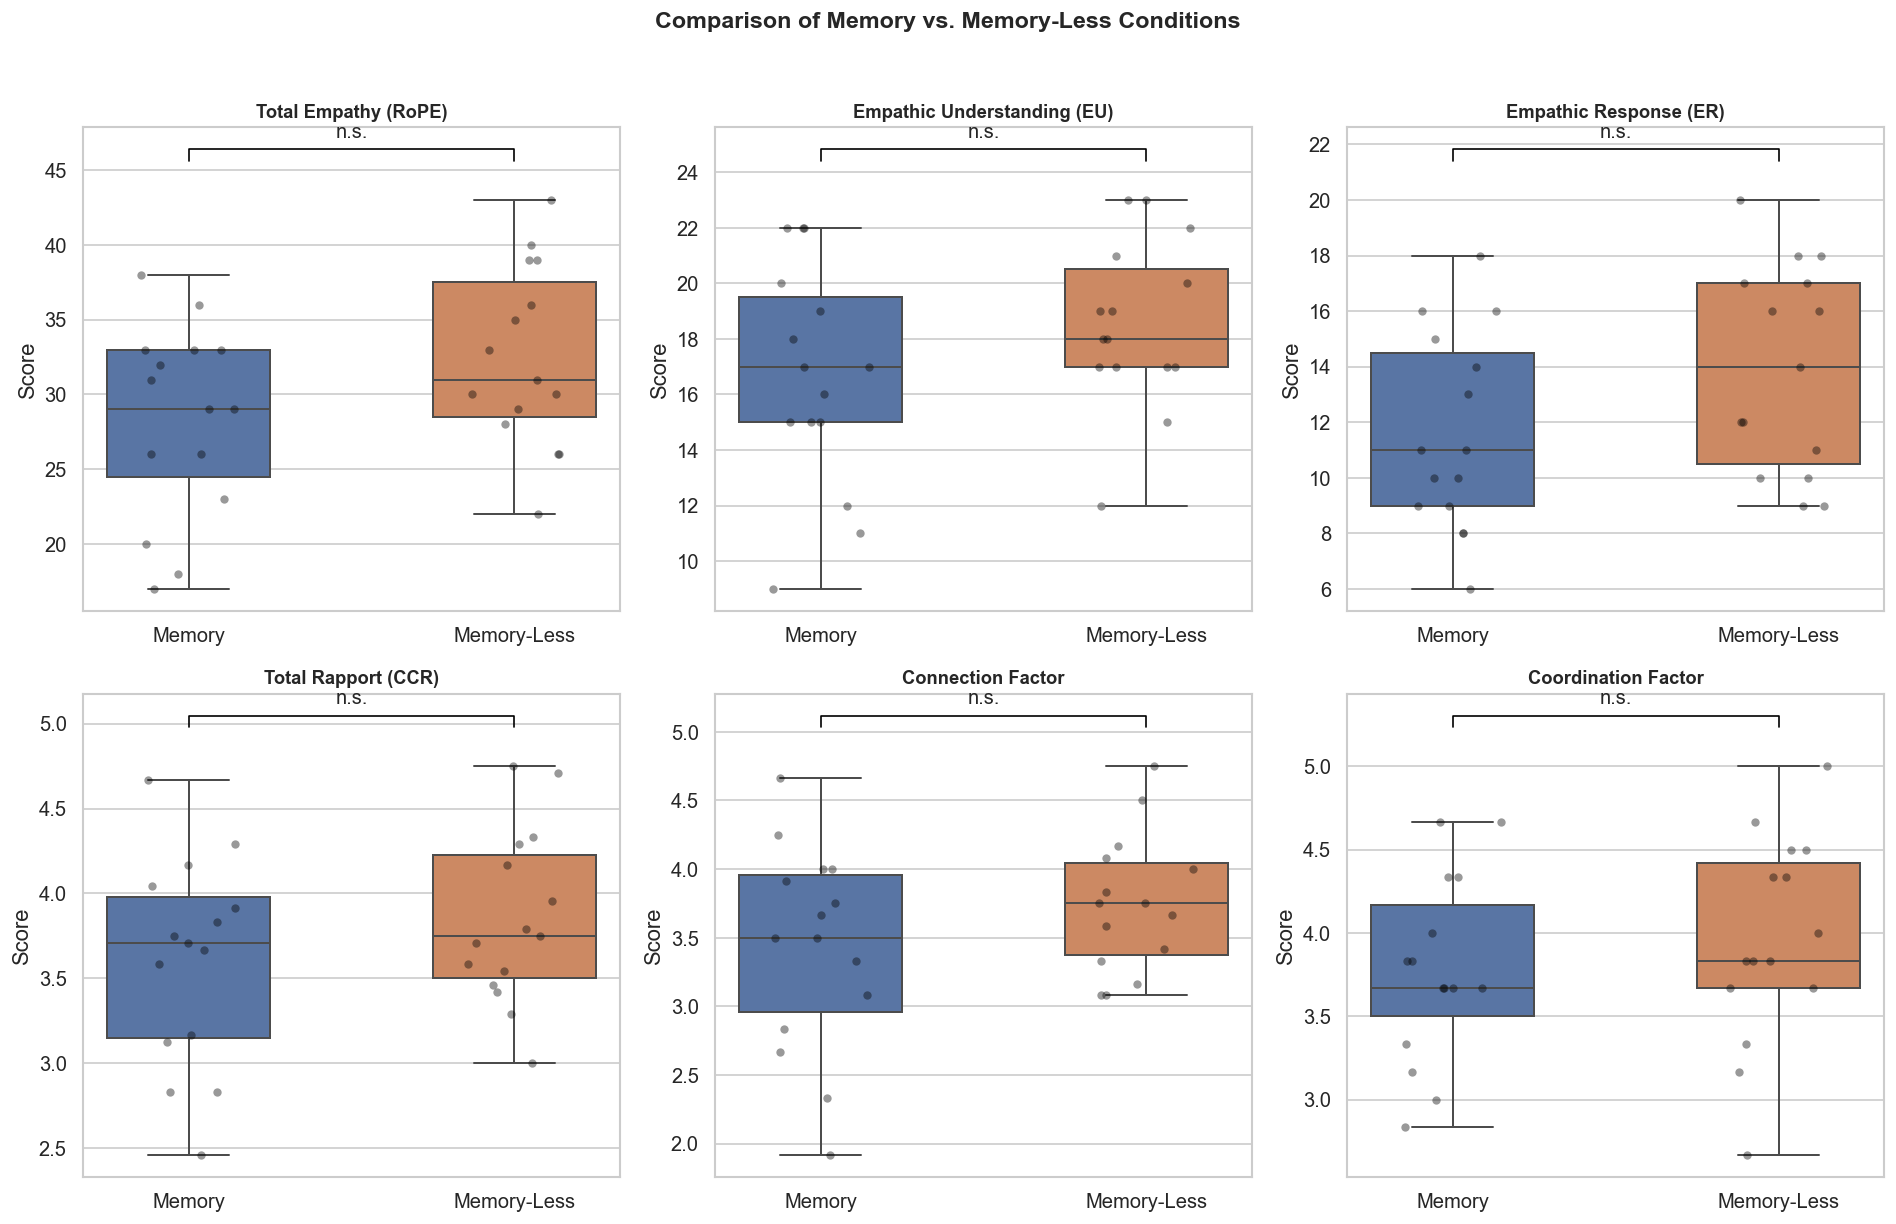

Figure saved: results_boxplots.png


In [21]:
# ============================================================
# Box + strip plots for all 6 metrics
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Comparison of Memory vs. Memory-Less Conditions', fontsize=14, fontweight='bold', y=1.02)

palette = {'Memory': '#4C72B0', 'Memory-Less': '#DD8452'}

for idx, metric in enumerate(metrics):
    ax = axes[idx // 3][idx % 3]
    
    # Box plot with individual data points
    sns.boxplot(data=df_scores, x='Condition', y=metric, ax=ax, palette=palette,
                width=0.5, linewidth=1.2, fliersize=0)
    sns.stripplot(data=df_scores, x='Condition', y=metric, ax=ax,
                  color='black', alpha=0.4, size=5, jitter=0.15)
    
    # Add significance annotation
    p_val = results[idx]['p (one-tailed)']
    if p_val < 0.001:
        sig_text = '***'
    elif p_val < 0.01:
        sig_text = '**'
    elif p_val < 0.05:
        sig_text = '*'
    else:
        sig_text = 'n.s.'
    
    # Draw bracket
    y_max = df_scores[metric].max()
    y_range = df_scores[metric].max() - df_scores[metric].min()
    bracket_y = y_max + y_range * 0.1
    ax.plot([0, 0, 1, 1], [bracket_y, bracket_y + y_range*0.03, bracket_y + y_range*0.03, bracket_y],
            color='black', linewidth=1)
    ax.text(0.5, bracket_y + y_range * 0.05, sig_text, ha='center', va='bottom', fontsize=12)
    
    ax.set_title(metric_labels[metric], fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Score')

plt.tight_layout()
plt.savefig('results_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results_boxplots.png')

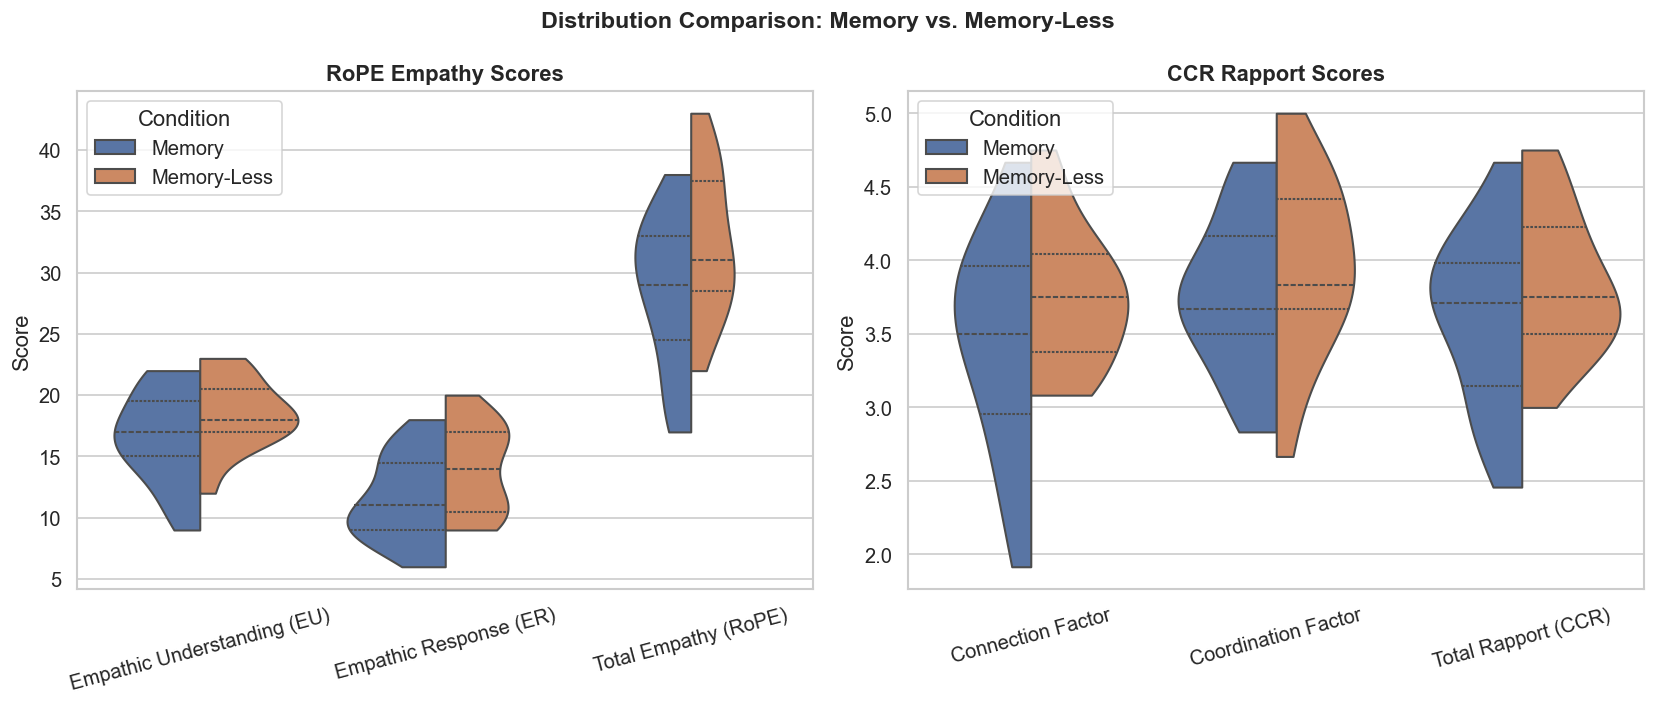

Figure saved: results_violinplots.png


In [22]:
# ============================================================
# Violin plots (alternative visualization)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribution Comparison: Memory vs. Memory-Less', fontsize=14, fontweight='bold')

# Empathy metrics
empathy_data = df_scores.melt(id_vars='Condition', 
                               value_vars=['EU_subscale', 'ER_subscale', 'Total_Empathy'],
                               var_name='Subscale', value_name='Score')
empathy_data['Subscale'] = empathy_data['Subscale'].map(metric_labels)

sns.violinplot(data=empathy_data, x='Subscale', y='Score', hue='Condition',
               split=True, ax=axes[0], palette=palette, inner='quart', cut=0)
axes[0].set_title('RoPE Empathy Scores', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Condition', loc='upper left')

# Rapport metrics
rapport_data = df_scores.melt(id_vars='Condition',
                               value_vars=['Connection', 'Coordination', 'Total_Rapport'],
                               var_name='Factor', value_name='Score')
rapport_data['Factor'] = rapport_data['Factor'].map(metric_labels)

sns.violinplot(data=rapport_data, x='Factor', y='Score', hue='Condition',
               split=True, ax=axes[1], palette=palette, inner='quart', cut=0)
axes[1].set_title('CCR Rapport Scores', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Condition', loc='upper left')

plt.tight_layout()
plt.savefig('results_violinplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results_violinplots.png')

---
## 7. Results Summary Table

Publication-ready results table with means, SDs, test statistics, p-values, and effect sizes.

In [23]:
# ============================================================
# Publication-ready results table
# ============================================================
summary_rows = []
for i, metric in enumerate(metrics):
    mem_data = df_scores[df_scores['Condition'] == 'Memory'][metric]
    ml_data = df_scores[df_scores['Condition'] == 'Memory-Less'][metric]
    r = results[i]
    
    p_val = r['p (one-tailed)']
    d_val = r["Cohen's d"]
    p_str = f'{p_val:.4f}' if p_val >= 0.001 else f'{p_val:.2e}'
    d_str = f'{d_val:.2f}'
    
    summary_rows.append({
        'Metric': metric_labels[metric],
        'Memory M (SD)': f'{mem_data.mean():.2f} ({mem_data.std(ddof=1):.2f})',
        'Memory-Less M (SD)': f'{ml_data.mean():.2f} ({ml_data.std(ddof=1):.2f})',
        'Test': r['Statistic'],
        'p': p_str,
        "Cohen's d": d_str,
        '95% CI': r["d 95% CI"]
    })

df_summary = pd.DataFrame(summary_rows)
print('Results Summary (α = 0.05, one-tailed)')
print('* p < 0.05, ** p < 0.01, *** p < 0.001')
print('=' * 110)
df_summary

Results Summary (α = 0.05, one-tailed)
* p < 0.05, ** p < 0.01, *** p < 0.001


,Metric,Memory M (SD),Memory-Less M (SD),Test,p,Cohen's d,95% CI
0,Total Empathy (RoPE),28.27 (6.45),32.47 (6.05),t(28) = -1.8396,0.9618,-0.67,"[-1.407, 0.064]"
1,Empathic Understanding (EU),16.67 (4.01),18.53 (3.00),t(28) = -1.4437,0.9200,-0.53,"[-1.255, 0.201]"
2,Empathic Response (ER),11.60 (3.54),13.93 (3.71),t(28) = -1.7614,0.9555,-0.64,"[-1.377, 0.091]"
3,Total Rapport (CCR),3.60 (0.61),3.85 (0.51),t(28) = -1.2022,0.8803,-0.44,"[-1.163, 0.285]"
4,Connection Factor,3.43 (0.75),3.74 (0.50),t(28) = -1.3662,0.9086,-0.50,"[-1.226, 0.228]"
5,Coordination Factor,3.78 (0.56),3.96 (0.62),t(28) = -0.8259,0.7921,-0.30,"[-1.021, 0.418]"


---
## 8. Normality Visualizations (Q-Q Plots)

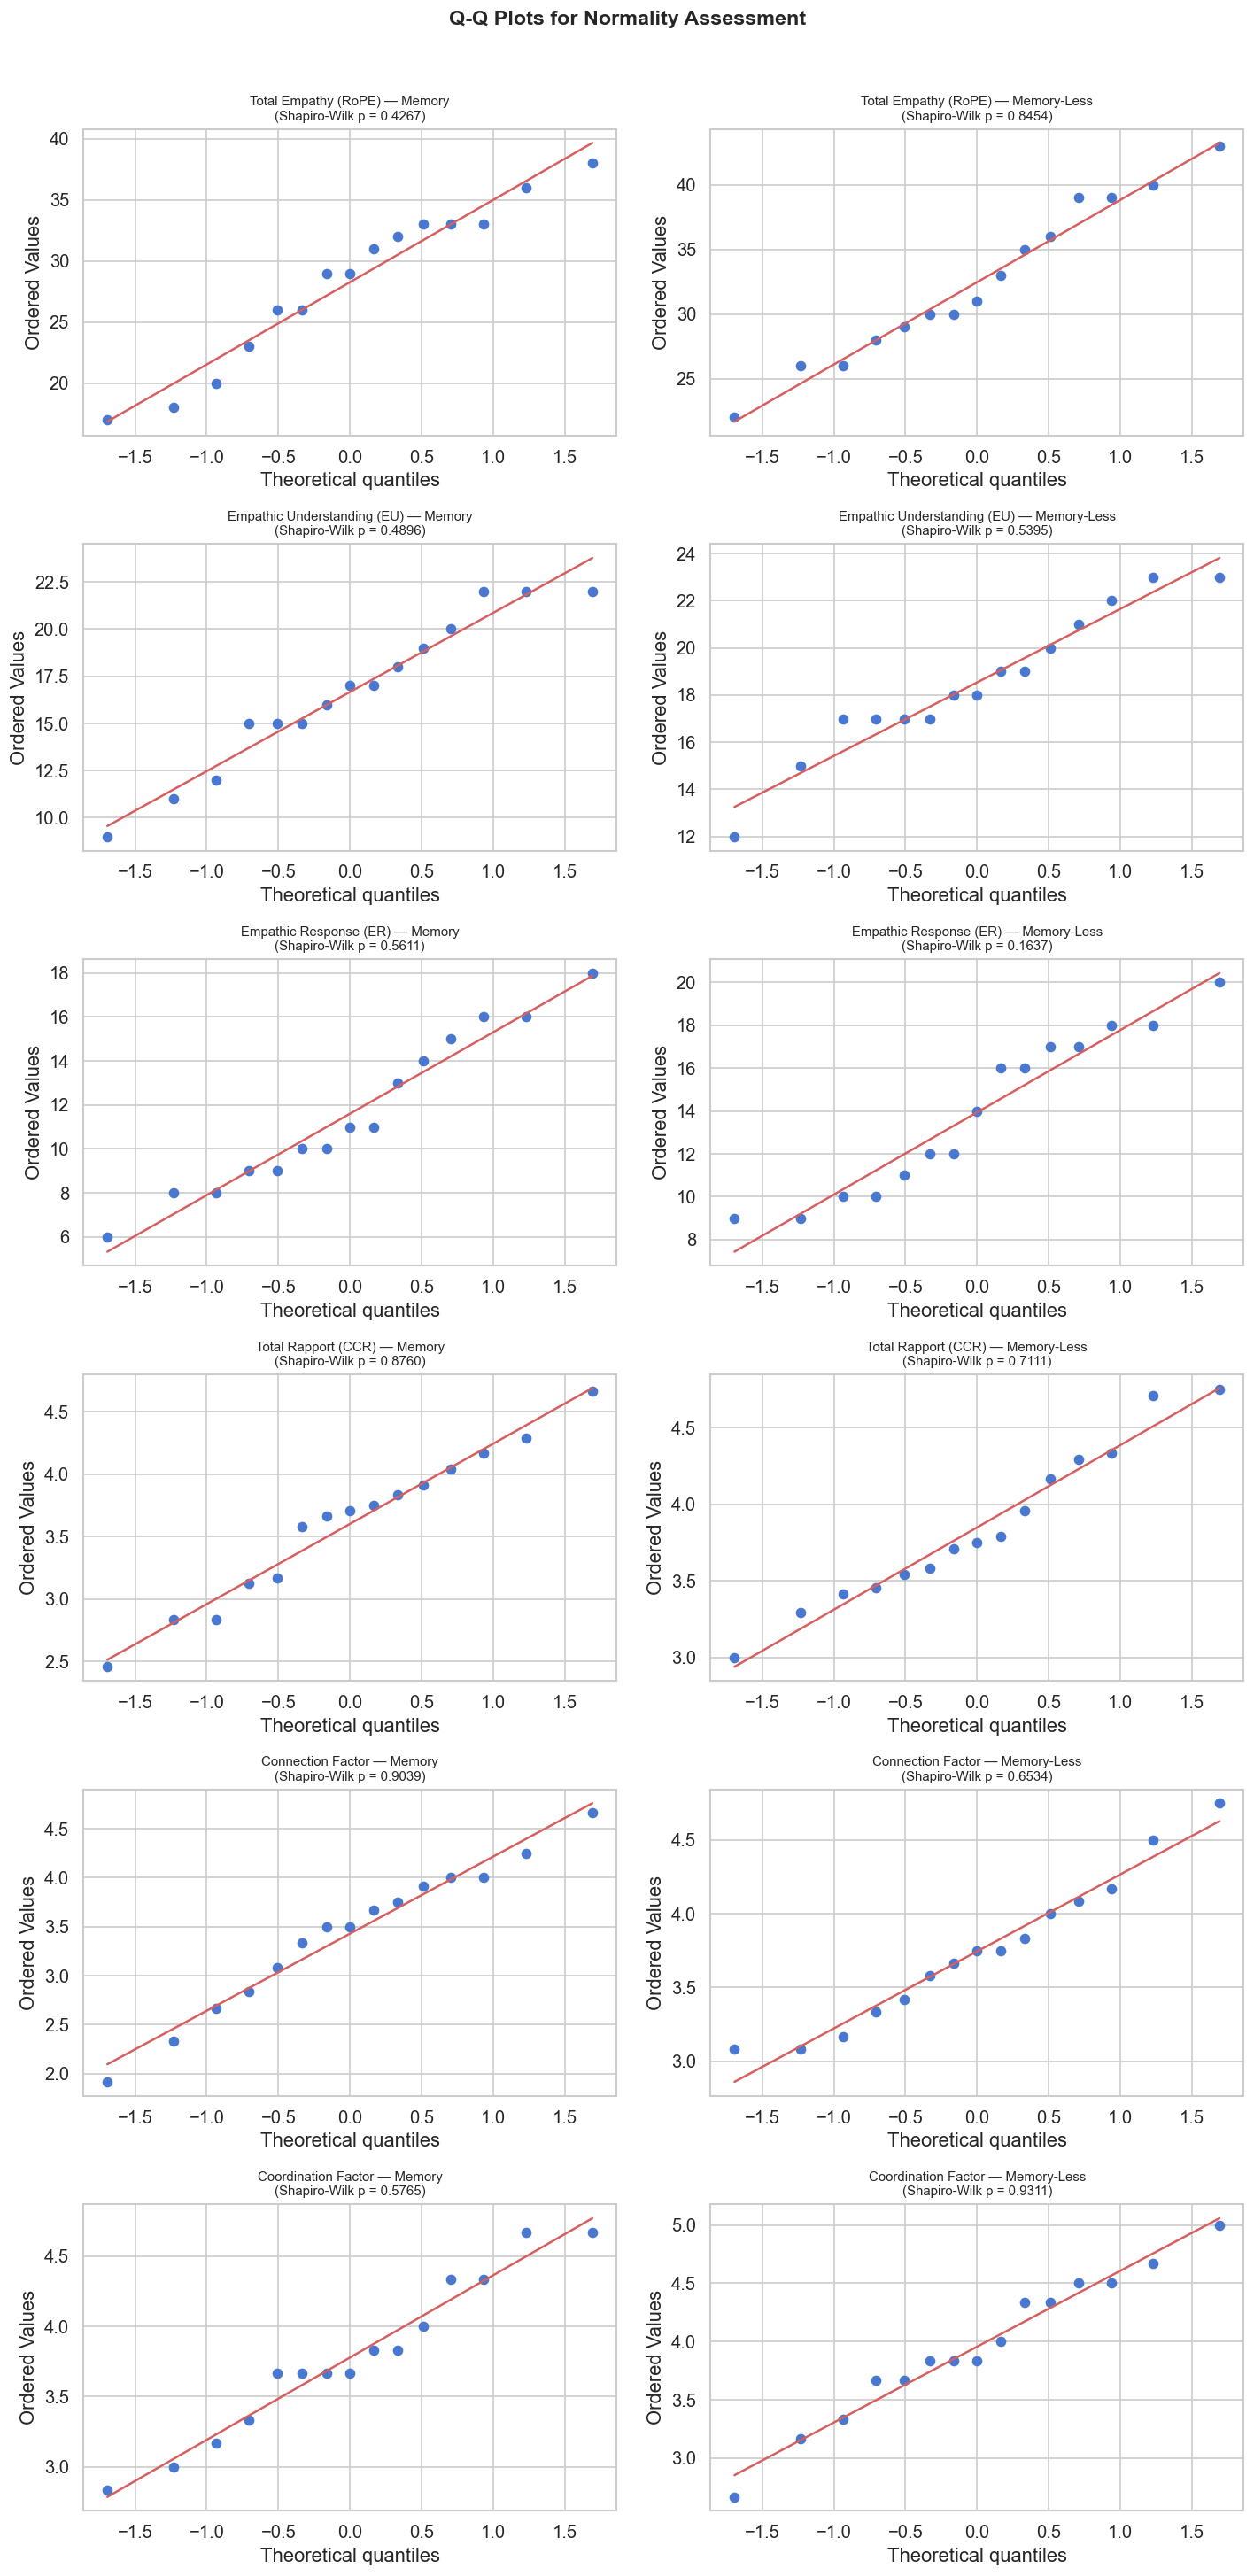

Figure saved: results_qqplots.png


In [24]:
# ============================================================
# Q-Q plots for normality visual inspection
# ============================================================
fig, axes = plt.subplots(6, 2, figsize=(12, 24))
fig.suptitle('Q-Q Plots for Normality Assessment', fontsize=14, fontweight='bold', y=1.01)

for idx, metric in enumerate(metrics):
    for j, condition in enumerate(['Memory', 'Memory-Less']):
        ax = axes[idx][j]
        data = df_scores[df_scores['Condition'] == condition][metric].values
        stats.probplot(data, dist='norm', plot=ax)
        
        # Get Shapiro-Wilk p-value for annotation
        _, sw_p = stats.shapiro(data)
        ax.set_title(f'{metric_labels[metric]} — {condition}\n(Shapiro-Wilk p = {sw_p:.4f})',
                     fontsize=9)

plt.tight_layout()
plt.savefig('results_qqplots.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: results_qqplots.png')